In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [8]:
df = pd.read_csv('student_performance.csv')

In [9]:
df.head()

,StudentID,Name,Gender,Age,Math,Science,English,Social,Attendance,City,EnrollmentDate
0,STU166,Currim Basnet,M,16.0,69.0,80.0,44.0,67.0,76.0,Bhaktapur,26/03/2023
1,STU135,Xena Gurung,female,18.0,54.0,74.0,NaN,51.0,100.0,Kathmandu,24/02/2023
2,STU159,Hari Gurung,Female,17.0,NaN,67.0,70.0,61.0,88.2,Lalitpur,11/04/2023
3,STU177,Nisha Karki,female,17.0,100.0,77.0,71.0,52.0,71.8,Butwal,2023-03-30
4,STU139,Quresh Karki,Female,18.0,53.0,42.0,59.0,76.0,82.1,Bhaktapur,08-31-2023


# How big is data 

In [10]:
df.shape

(106, 11)

# Are there any Missing Values

In [11]:
df.isnull().sum()

StudentID         0
Name              0
Gender            3
Age               2
Math              7
Science           7
English           4
Social            5
Attendance        7
City              3
EnrollmentDate    0
dtype: int64

# How does data looks like 

In [12]:
df.sample(5)

,StudentID,Name,Gender,Age,Math,Science,English,Social,Attendance,City,EnrollmentDate
89,STU118,Zara Magar,M,18.0,59.0,77.0,64.0,79.0,76.9,Dharan,02-25-2023
58,STU149,Tara Gurung,Male,14.0,42.0,NaN,46.0,63.0,83.6,Lalitpur,2024-06-01
86,STU128,Quresh Gurung,Female,14.0,67.0,94.0,55.0,88.0,89.7,Pokhara,07-27-2023
3,STU177,Nisha Karki,female,17.0,100.0,77.0,71.0,52.0,71.8,Butwal,2023-03-30
51,STU189,Bimala Basnet,M,14.0,57.0,49.0,65.0,98.0,80.2,Lalitpur,02-05-2023


# What are the datatype of Columns

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   StudentID       106 non-null    object 
 1   Name            106 non-null    object 
 2   Gender          103 non-null    object 
 3   Age             104 non-null    float64
 4   Math            99 non-null     float64
 5   Science         99 non-null     float64
 6   English         102 non-null    float64
 7   Social          101 non-null    float64
 8   Attendance      99 non-null     float64
 9   City            103 non-null    object 
 10  EnrollmentDate  106 non-null    object 
dtypes: float64(6), object(5)
memory usage: 9.2+ KB


# How does the data looks like Mathmatically

In [14]:
df.describe()

,Age,Math,Science,English,Social,Attendance
count,104.000000,99.000000,99.000000,102.000000,101.000000,99.000000
mean,15.903846,63.090909,64.454545,67.421569,63.653465,84.130303
std,1.510605,17.218340,17.170378,14.617524,16.345296,9.549479
min,14.000000,19.000000,24.000000,33.000000,19.000000,59.400000
25%,15.000000,52.000000,52.500000,58.250000,53.000000,78.800000
50%,16.000000,63.000000,67.000000,68.000000,63.000000,83.600000
75%,17.000000,71.000000,76.500000,76.750000,73.000000,90.600000
max,18.000000,100.000000,100.000000,100.000000,100.000000,100.000000


# Are there are Duplicat Values

In [15]:
df.duplicated().sum()

np.int64(6)

# Removing the Duplicate Values 

In [16]:
df = df.drop_duplicates()  

# Checking the Remove  Duplicate Values

In [17]:
df.duplicated().sum()

np.int64(0)

# How is the Correlationship between the columns

In [18]:
df.corr(numeric_only=True)

,Age,Math,Science,English,Social,Attendance
Age,1.000000,-0.252109,-0.082744,0.074683,0.010223,0.015466
Math,-0.252109,1.000000,0.003721,0.112199,0.113188,-0.061417
Science,-0.082744,0.003721,1.000000,-0.202906,-0.133295,-0.046958
English,0.074683,0.112199,-0.202906,1.000000,0.073271,0.268210
Social,0.010223,0.113188,-0.133295,0.073271,1.000000,0.040727
Attendance,0.015466,-0.061417,-0.046958,0.268210,0.040727,1.000000


# EDA (Univariate Analysis )

# Bar chart

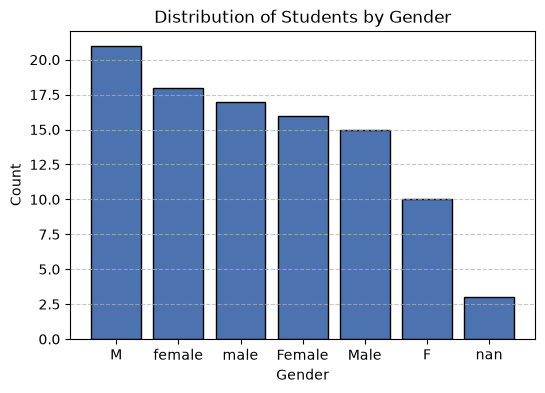

In [19]:
gender_counts = df['Gender'].value_counts(dropna=False).rename(index={float('nan'): 'Missing'})

plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index.astype(str), gender_counts.values, color='#4C72B0', edgecolor='black')
plt.title('Distribution of Students by Gender', fontsize=12)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bar chart City 

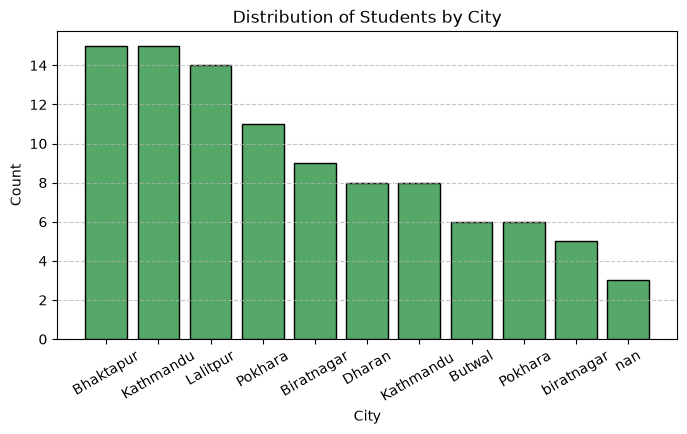

In [20]:
city_counts = df['City'].value_counts(dropna=False).rename(index={float('nan'): 'Missing'})

plt.figure(figsize=(8, 4))
plt.bar(city_counts.index.astype(str), city_counts.values, color='#55A868', edgecolor='black')
plt.title('Distribution of Students by City', fontsize=12)
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Pie Charts (Categorical Proportions)

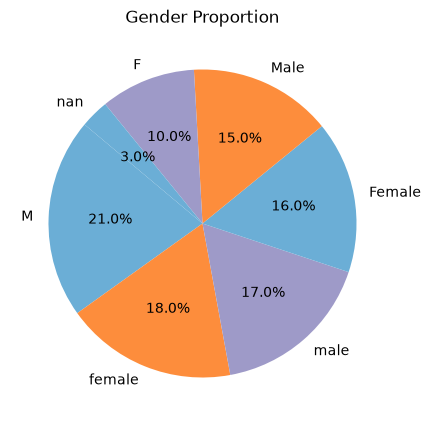

In [21]:
plt.figure(figsize=(5, 5))
plt.pie(gender_counts.values, labels=gender_counts.index.astype(str), autopct='%1.1f%%', startangle=140, colors=['#6baed6', '#fd8d3c', '#9e9ac8'])
plt.title('Gender Proportion', fontsize=12)
plt.show()

# Pie Chart: City Share

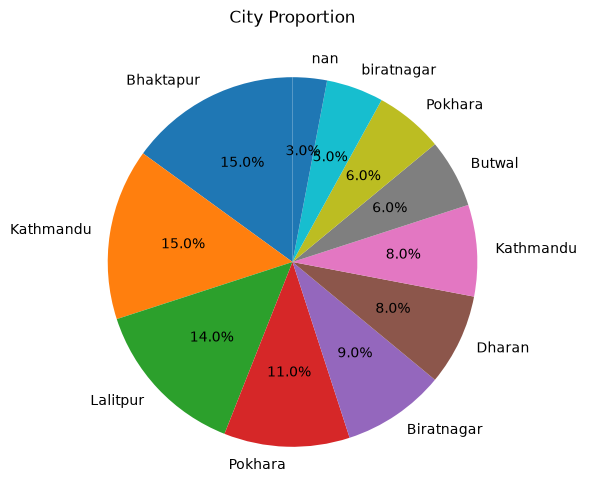

In [22]:
plt.figure(figsize=(6, 6))
plt.pie(city_counts.values, labels=city_counts.index.astype(str), autopct='%1.1f%%', startangle=90)
plt.title('City Proportion', fontsize=12)
plt.show()

# Histograms (Continuous Value Spread & Skewness)

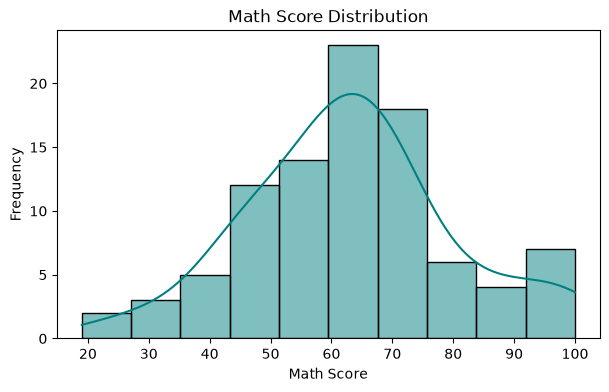

In [23]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Math'].dropna(), kde=True, bins=10, color='teal', edgecolor='black')
plt.title('Math Score Distribution', fontsize=12)
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

# Histogram: Attendance

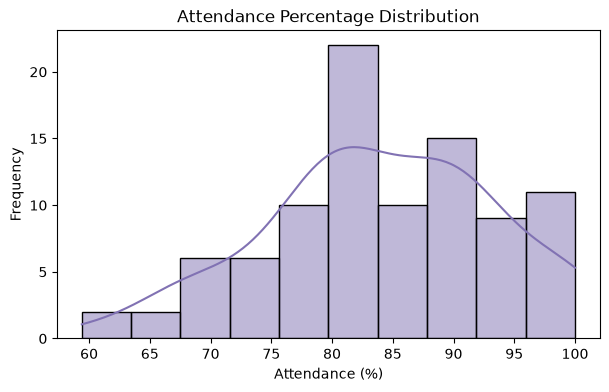

In [24]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Attendance'].dropna(), kde=True, bins=10, color='#8172B3', edgecolor='black')
plt.title('Attendance Percentage Distribution', fontsize=12)
plt.xlabel('Attendance (%)')
plt.ylabel('Frequency')
plt.show()

# Histograms for All Scores (Loop)

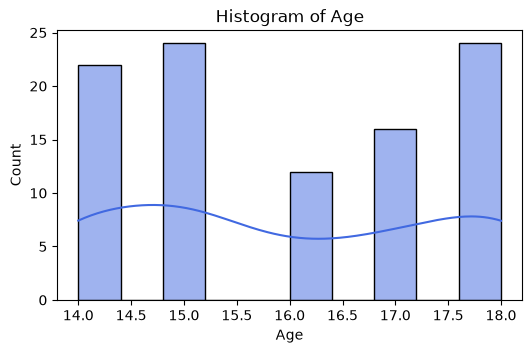

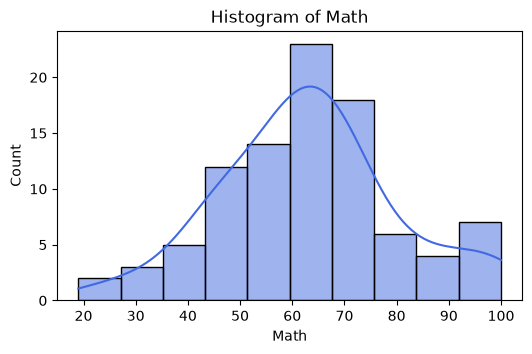

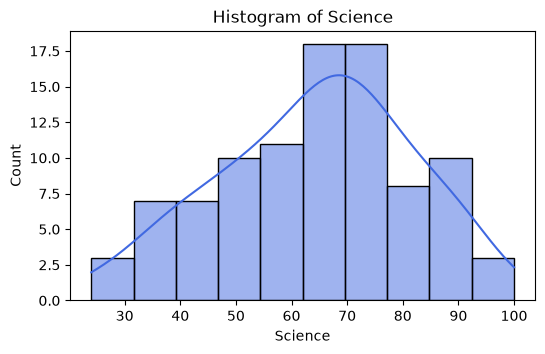

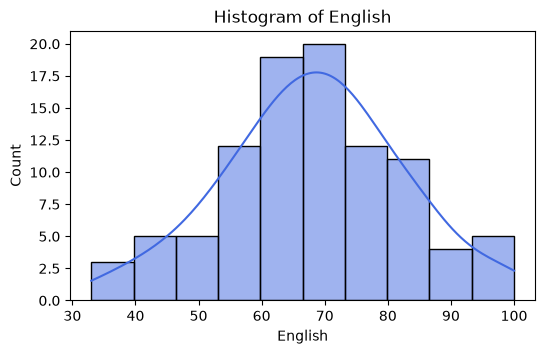

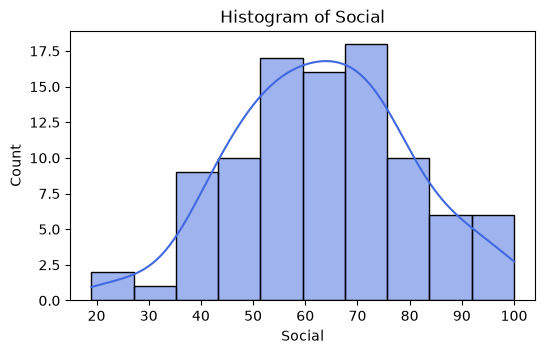

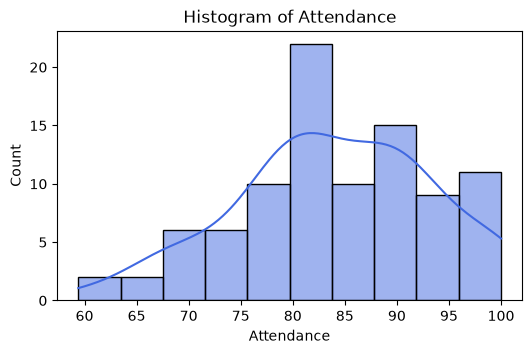

In [25]:
num_cols = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance']

for col in num_cols:
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df[col].dropna(), kde=True, bins=10, color='royalblue', edgecolor='black')
    plt.title(f'Histogram of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Boxplots (Outliers & Quartile Distribution)

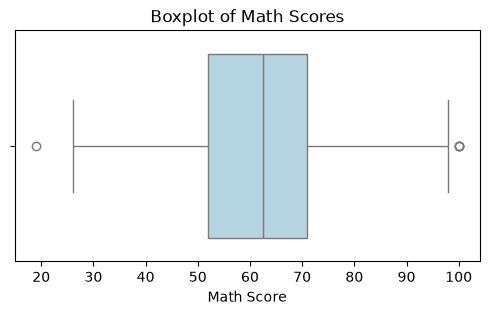

In [26]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Math'], color='lightblue')
plt.title('Boxplot of Math Scores', fontsize=12)
plt.xlabel('Math Score')
plt.show()

# Boxplot: Attendance

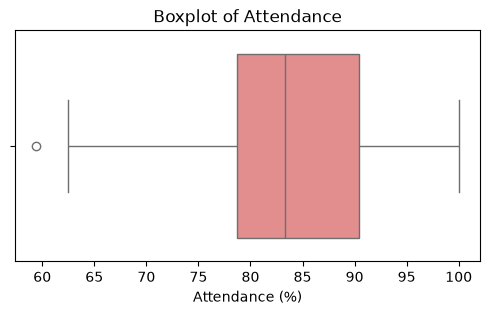

In [27]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Attendance'], color='lightcoral')
plt.title('Boxplot of Attendance', fontsize=12)
plt.xlabel('Attendance (%)')
plt.show()

# Boxplot: Comparing All Academic Subjects Together

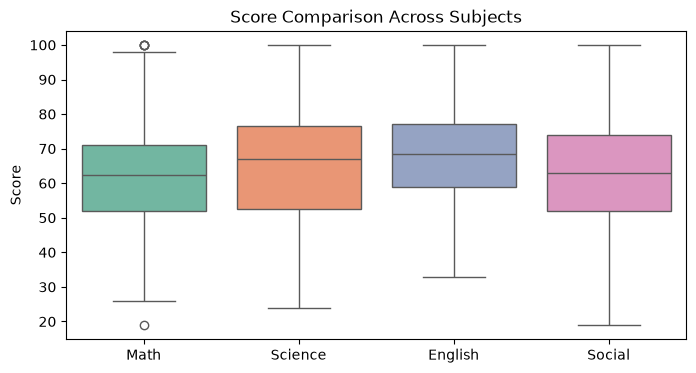

In [28]:
subjects = ['Math', 'Science', 'English', 'Social']

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[subjects], palette='Set2')
plt.title('Score Comparison Across Subjects', fontsize=12)
plt.ylabel('Score')
plt.show()

#  Bivariate & Multivariate Analysis

# Correlation Matrix Heatmap (Multivariate)

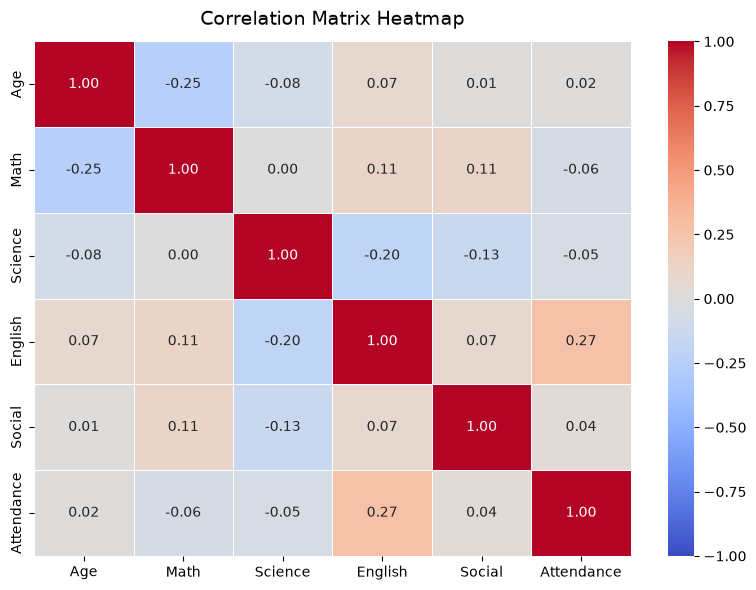

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix Heatmap", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Pairplot (Multivariate & Bivariate Overview)

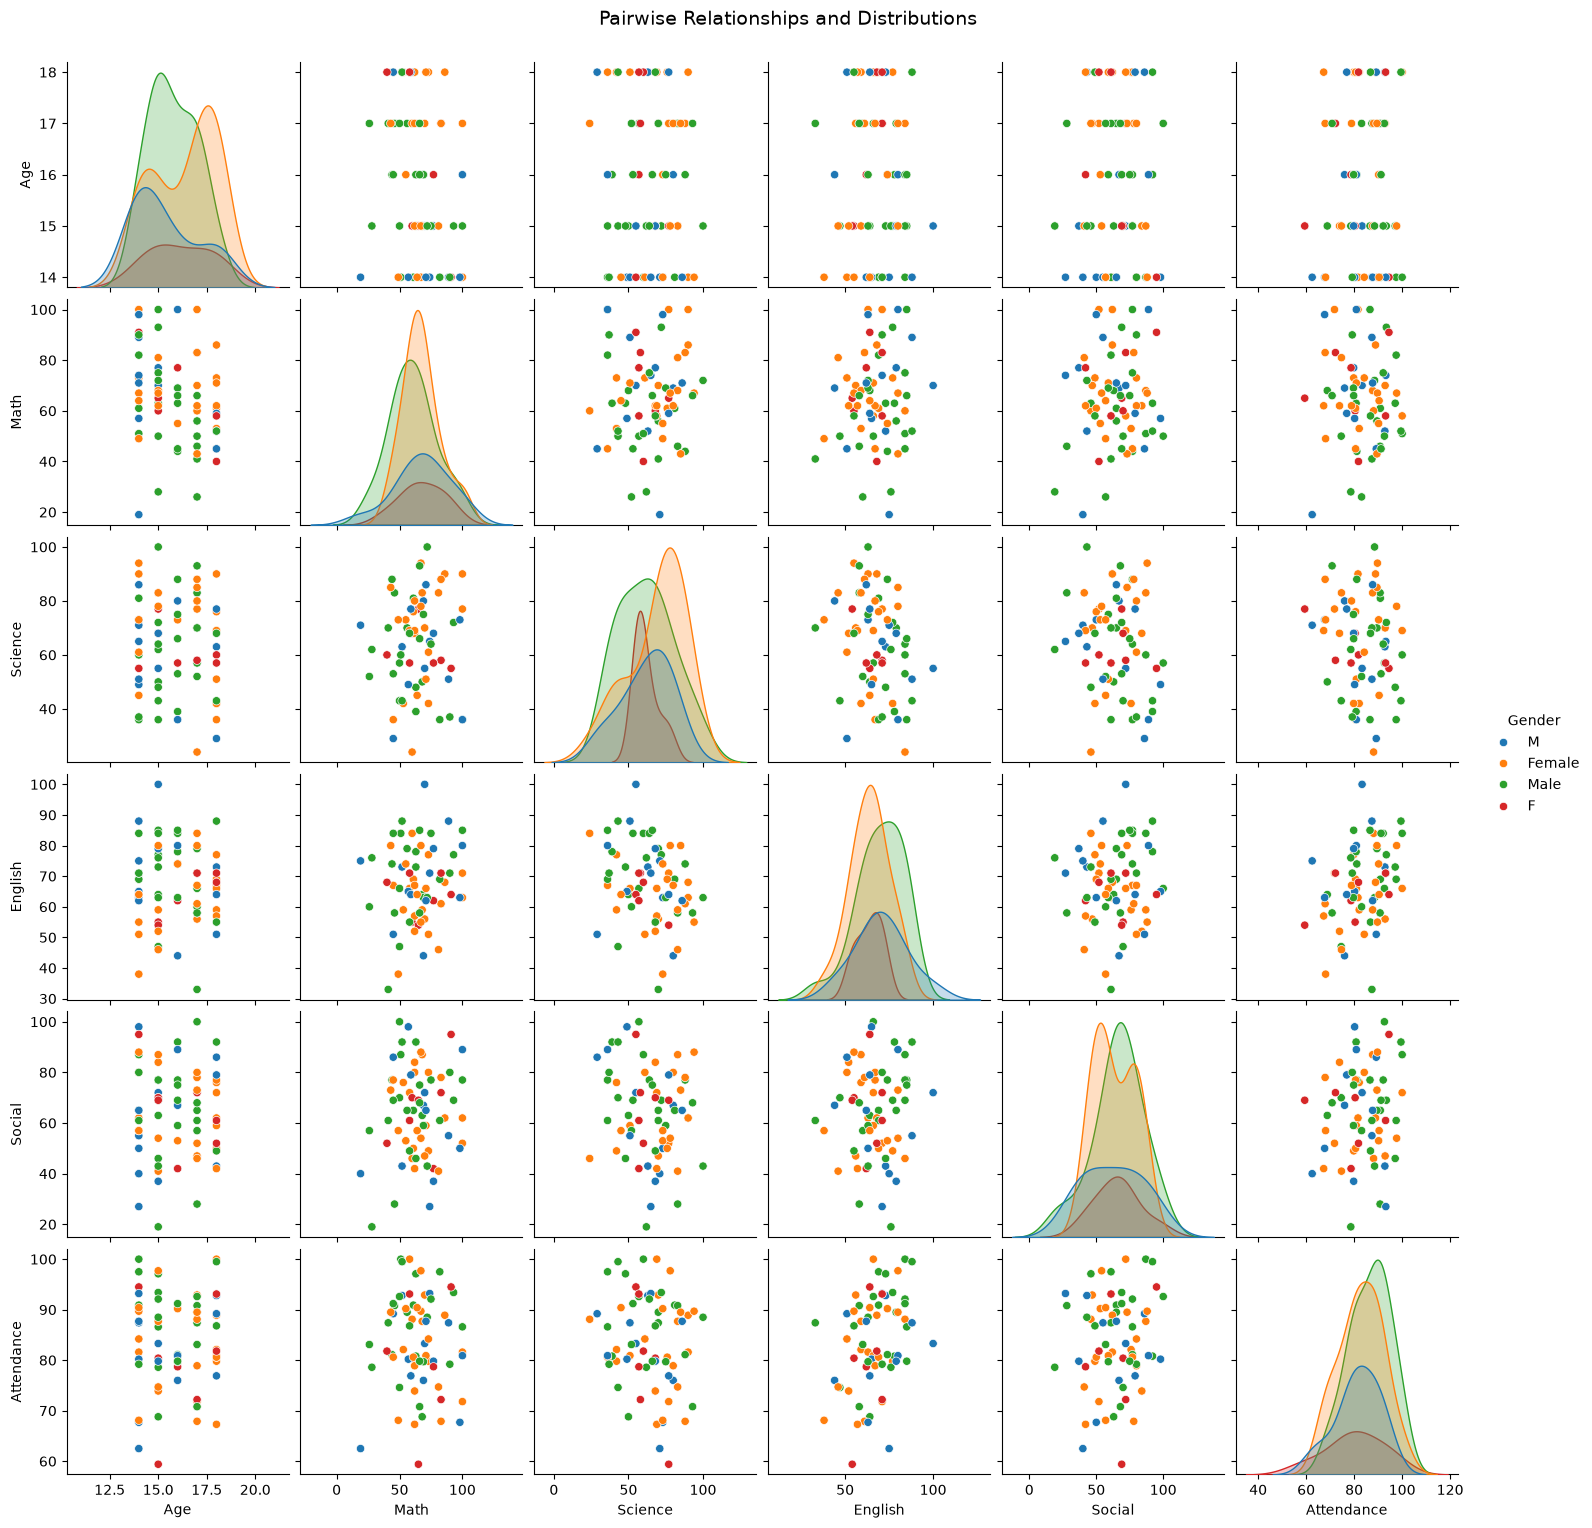

In [30]:
# Standardize Gender casing first if not done already
df['Gender'] = df['Gender'].str.capitalize()

numeric_cols = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance']

sns.pairplot(
    df[numeric_cols + ['Gender']].dropna(),
    hue='Gender',
    diag_kind='kde',
    corner=False  # Set corner=True to hide the redundant upper triangle
)
plt.suptitle("Pairwise Relationships and Distributions", y=1.02, fontsize=14)
plt.show()

# Scatterplots (Bivariate Relationships)

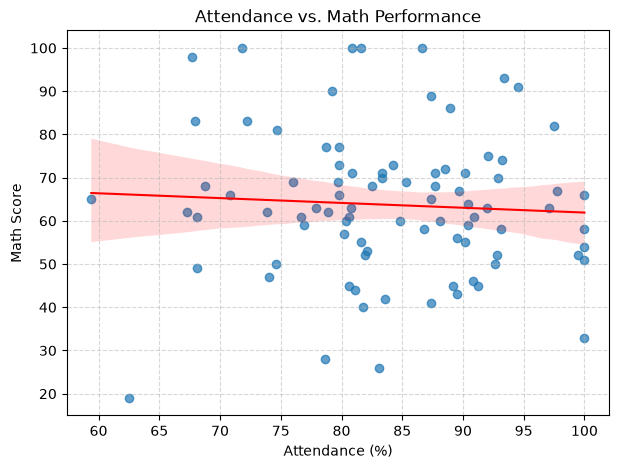

In [31]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x='Attendance',
    y='Math',
    scatter_kws={'alpha': 0.7, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 1.5}
)
plt.title("Attendance vs. Math Performance", fontsize=12)
plt.xlabel("Attendance (%)")
plt.ylabel("Math Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Science vs. Math Scores (Grouped by Gender)

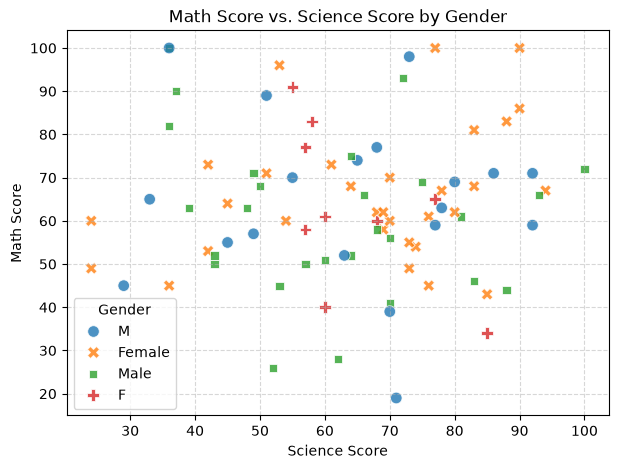

In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='Science',
    y='Math',
    hue='Gender',
    style='Gender',
    s=70,
    alpha=0.8
)
plt.title("Math Score vs. Science Score by Gender", fontsize=12)
plt.xlabel("Science Score")
plt.ylabel("Math Score")
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Age vs. English Score (Grouped by City)

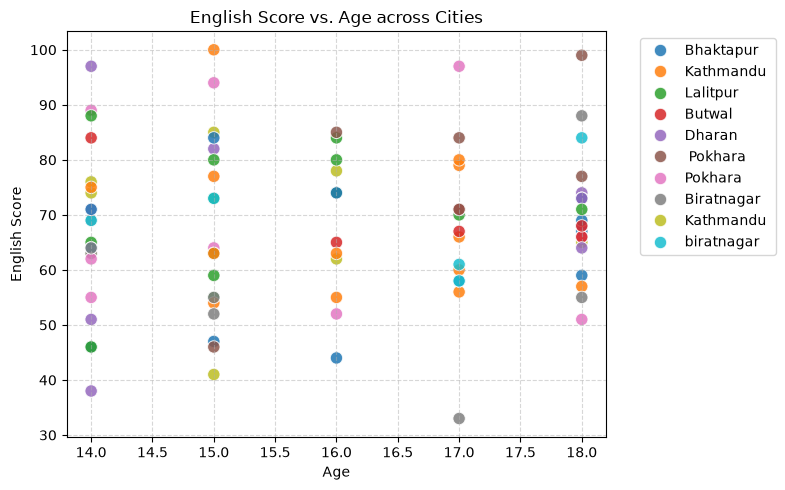

In [33]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Age',
    y='English',
    hue='City',
    s=80,
    alpha=0.85
)
plt.title("English Score vs. Age across Cities", fontsize=12)
plt.xlabel("Age")
plt.ylabel("English Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
# Initialize the profile report
profile = ProfileReport(
    df,
    title="Student Performance EDA Report",
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████| 11/11 [00:00<00:00, 1185.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
# Save to a local HTML file
profile.to_file("student_performance_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# # Data Cleaning & Imputation

In [36]:
# Ensure we work on a detached copy to avoid SettingWithCopy warnings
df_clean = df.copy()

In [37]:
# 1. Standardize string casing
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip().str.capitalize()
df_clean['Gender'] = df_clean['Gender'].replace('Nan', np.nan)

df_clean['City'] = df_clean['City'].astype(str).str.strip()
df_clean['City'] = df_clean['City'].replace('Nan', np.nan)

In [38]:
# 3. Numerical Imputation (using median)
num_cols = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [39]:
# 4. Categorical Imputation (using mode)
cat_cols = ['Gender', 'City']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [40]:
print("Missing values remaining:\n", df_clean.isnull().sum())

Missing values remaining:
 StudentID         0
Name              0
Gender            0
Age               0
Math              0
Science           0
English           0
Social            0
Attendance        0
City              0
EnrollmentDate    0
dtype: int64


# # Feature Engineering 

In [41]:
# 1. Academic Aggregates
df_clean['Total_Score'] = df_clean['Math'] + df_clean['Science'] + df_clean['English'] + df_clean['Social']
df_clean['Average_Score'] = df_clean['Total_Score'] / 4

# 2. Define a Classification Target (1 = Passed, 0 = At Risk / Failed)
df_clean['Passed'] = (df_clean['Average_Score'] >= 50).astype(int)

# 3. Explicitly convert to datetime first, then extract components
df_clean['EnrollmentDate'] = pd.to_datetime(df_clean['EnrollmentDate'], format='mixed', errors='coerce')
df_clean['Enrollment_Year'] = df_clean['EnrollmentDate'].dt.year
df_clean['Enrollment_Month'] = df_clean['EnrollmentDate'].dt.month

# 4. Drop non-predictive identifiers and raw dates
df_model = df_clean.drop(columns=['StudentID', 'Name', 'EnrollmentDate'])

print(df_model.head())

   Gender   Age   Math  Science  English  Social  Attendance       City  \
0       M  16.0   69.0     80.0     44.0    67.0        76.0  Bhaktapur   
1  Female  18.0   54.0     74.0     68.5    51.0       100.0  Kathmandu   
2  Female  17.0   62.5     67.0     70.0    61.0        88.2   Lalitpur   
3  Female  17.0  100.0     77.0     71.0    52.0        71.8     Butwal   
4  Female  18.0   53.0     42.0     59.0    76.0        82.1  Bhaktapur   

   Total_Score  Average_Score  Passed  Enrollment_Year  Enrollment_Month  
0        260.0         65.000       1             2023                 3  
1        247.5         61.875       1             2023                 2  
2        260.5         65.125       1             2023                11  
3        300.0         75.000       1             2023                 3  
4        230.0         57.500       1             2023                 8  


# # Encoding 

In [42]:
# Separate predictors and target
X = df_model.drop(columns=['Passed', 'Total_Score', 'Average_Score'])
y = df_model['Passed']

print(f"X shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape: (100, 10)
Target distribution:
Passed
1    96
0     4
Name: count, dtype: int64


# Train-Test Split with Stratification

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (80, 10)
X_test shape: (20, 10)


# Group Columns by Data Type

In [44]:
# Identify feature groups
num_features = [
    'Age', 'Math', 'Science', 'English', 
    'Social', 'Attendance', 'Enrollment_Year', 'Enrollment_Month'
]

cat_features = ['Gender', 'City']

print(f"Numeric columns: {num_features}")
print(f"Categorical columns: {cat_features}")

Numeric columns: ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance', 'Enrollment_Year', 'Enrollment_Month']
Categorical columns: ['Gender', 'City']


# #Construct the Preprocessing Pipeline

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='passthrough'
)

print("Preprocessor constructed:")
print(preprocessor)

Preprocessor constructed:
ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Age', 'Math', 'Science', 'English', 'Social',
                                  'Attendance', 'Enrollment_Year',
                                  'Enrollment_Month']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Gender', 'City'])])


# Fit on Training Data & Transform (Verification Check)

In [46]:
# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Retrieve transformed column names
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_names)

# Convert to DataFrame to inspect results
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
print(f"Processed feature matrix shape: {X_train_processed_df.shape}")
display(X_train_processed_df.head())

Processed feature matrix shape: (80, 19)


,Age,Math,Science,English,Social,Attendance,Enrollment_Year,Enrollment_Month,Gender_Female,Gender_M,Gender_Male,City_Biratnagar,City_Butwal,City_Dharan,City_Kathmandu,City_Lalitpur,City_Pokhara,City_biratnagar,City_nan
0,1.408805,1.358836,1.481206,-0.007018,-0.103380,0.654656,-0.927613,1.202254,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.050921,0.793146,-0.437530,-0.428074,-1.301986,-0.482180,1.078036,0.621104,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.408805,-0.338236,0.725341,-0.287722,0.915435,-0.682798,-0.927613,-1.122346,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.729863,-0.275381,-2.356266,1.115800,-1.062264,0.565492,-0.927613,0.621104,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.628021,2.238800,-1.658544,1.185976,0.795575,0.398310,-0.927613,-0.831771,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# # Build Machine Learning Pipelines

In [47]:
# 1. Logistic Regression Pipeline (Linear Baseline)
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# 2. Decision Tree Pipeline (Single Rule-Based Model)
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

# 3. Random Forest Pipeline (Ensemble of Trees)
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

print("Pipelines successfully created.")

Pipelines successfully created.


# Train  Models on Training Data

In [48]:
# Train all models
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


# Cross-Validation Check (Training Stability)

In [49]:
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configure 3 stratified folds because min class count in train set is 3
cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf
}

print("3-Fold Cross-Validation Accuracy (Training Set):")

# Suppress benign encoder zero-fill warnings during cross-validation
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=cv_stratified, scoring='accuracy')
        print(f"* {name}: Mean = {scores.mean():.4f} (Std = {scores.std():.4f})")

3-Fold Cross-Validation Accuracy (Training Set):
* Logistic Regression: Mean = 0.9625 (Std = 0.0007)
* Decision Tree: Mean = 0.9630 (Std = 0.0302)
* Random Forest: Mean = 0.9625 (Std = 0.0007)


#  Generate Test Set Predictions

In [50]:
# Generate class predictions
y_pred_lr = pipe_lr.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

# Generate probability scores (needed for ROC-AUC analysis)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

# Combine into a preview DataFrame
results_preview = pd.DataFrame({
    'Actual': y_test.values,
    'Pred_LogisticRegression': y_pred_lr,
    'Pred_DecisionTree': y_pred_dt,
    'Pred_RandomForest': y_pred_rf,
    'RF_Probability_Pass': np.round(y_proba_rf, 3)
})

display(results_preview.head(10))

,Actual,Pred_LogisticRegression,Pred_DecisionTree,Pred_RandomForest,RF_Probability_Pass
0,1,1,1,1,0.998
1,1,1,1,1,0.958
2,1,1,1,1,1.000
3,1,1,1,1,0.980
4,1,1,1,1,0.990
5,1,1,1,1,0.920
6,1,1,1,1,0.990
7,1,1,1,1,1.000
8,1,1,1,1,1.000
9,1,1,1,1,0.990


# # Model Evaluation & Feature Importance 

# Generate Classification Reports & Summary Metrics

In [51]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print("=" * 55)
    print(f"Model: {name}")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1-Score:   {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print("-" * 55)
    print(classification_report(y_test, y_pred, zero_division=0))

Model: Logistic Regression
Overall Accuracy: 0.9000
Macro F1-Score:   0.4737
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      0.95      0.95        19

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20

Model: Decision Tree
Overall Accuracy: 0.9000
Macro F1-Score:   0.4737
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      0.95      0.95        19

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20

Model: Random Forest
Overall Accuracy: 0.9500
Macro F1-Score:   0.4872
---------------

# Confusion Matrix Comparison Heatmaps

NameError: name 'confusion_matrix' is not defined

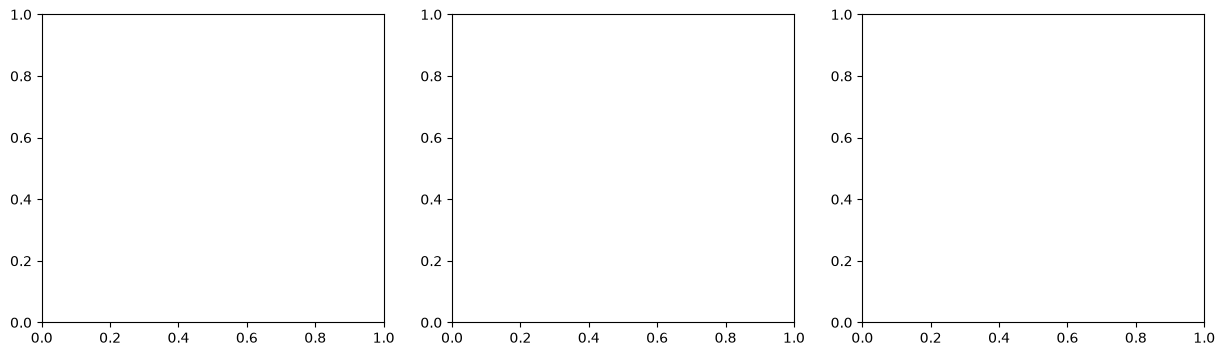

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        ax=ax,
        xticklabels=['Fail (0)', 'Pass (1)'],
        yticklabels=['Fail (0)', 'Pass (1)']
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ROC-AUC Curves(Receiver Operating Characteristic)

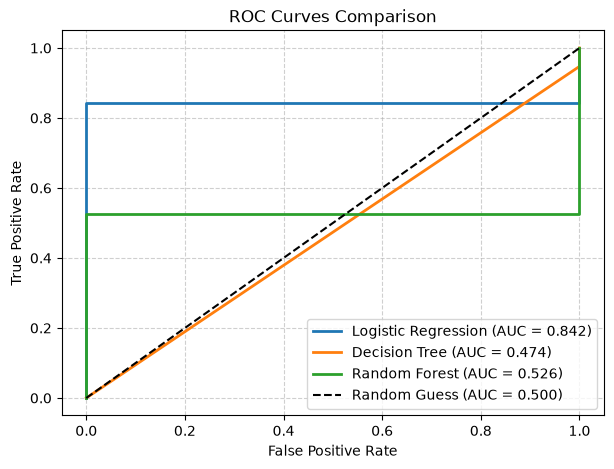

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 5))

for name, model in models.items():
    # Retrieve predicted probabilities for positive class (Pass = 1)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_proba)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Feature Importance Extraction (Random Forest & Decision Tree)

In [54]:
# 1. Recover full feature names after One-Hot Encoding
encoded_cat_names = pipe_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_names)

# 2. Extract importance vectors
rf_importances = pipe_rf.named_steps['classifier'].feature_importances_
dt_importances = pipe_dt.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Random_Forest': rf_importances,
    'Decision_Tree': dt_importances
}).sort_values(by='Random_Forest', ascending=False).reset_index(drop=True)

display(importance_df)

,Feature,Random_Forest,Decision_Tree
0,Math,0.333422,0.65812
1,Social,0.194082,0.17316
2,Science,0.129327,0.16872
3,City_Kathmandu,0.082466,0.00000
4,English,0.062113,0.00000
5,City_nan,0.046536,0.00000
6,Attendance,0.042805,0.00000
7,Age,0.035435,0.00000
8,Enrollment_Month,0.025859,0.00000
9,Gender_Female,0.013395,0.00000


In [55]:
# 1. Fix casing & unify mappings
df_clean['Gender'] = df_clean['Gender'].replace({'M': 'Male', 'F': 'Female', 'female': 'Female', 'male': 'Male'})
df_clean['City'] = df_clean['City'].str.strip().str.title()

# 2. Re-impute missing values properly so 'nan' strings do not become categories
df_clean['Gender'] = df_clean['Gender'].replace(['Nan', 'None', np.nan], df_clean['Gender'].mode()[0])
df_clean['City'] = df_clean['City'].replace(['Nan', 'None', np.nan], df_clean['City'].mode()[0])

print("Unique Genders:", df_clean['Gender'].unique())
print("Unique Cities:", df_clean['City'].unique())

Unique Genders: ['Male' 'Female']
Unique Cities: ['Bhaktapur' 'Kathmandu' 'Lalitpur' 'Butwal' 'Dharan' 'Pokhara'
 'Biratnagar']


# Feature Importance Visualization

/var/folders/yx/1w14ycn52pgb0066g3nsr61c0000gn/T/ipykernel_24027/946636050.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


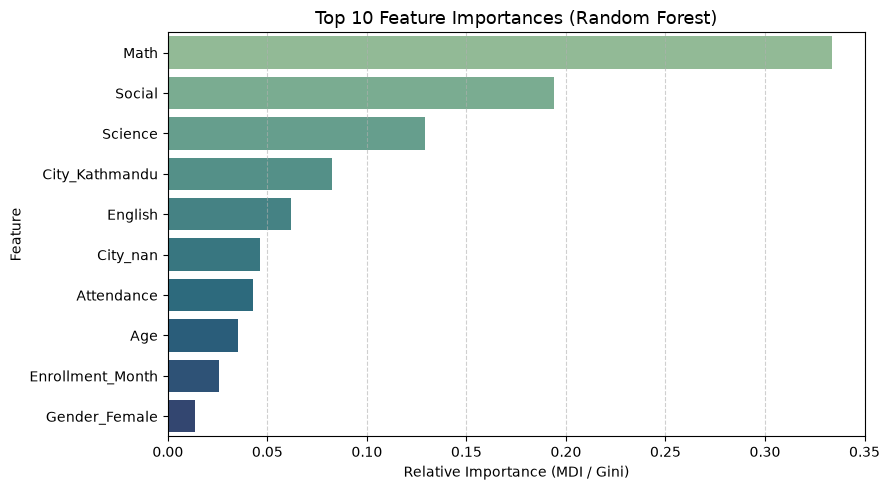

In [56]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_df.head(10),
    x='Random_Forest', 
    y='Feature', 
    palette='crest'
)
plt.title("Top 10 Feature Importances (Random Forest)", fontsize=13)
plt.xlabel("Relative Importance (MDI / Gini)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Logistic Regression Odds Ratios (Feature Coefficients)

In [57]:
# Extract linear weights
lr_coefs = pipe_lr.named_steps['classifier'].coef_[0]

odds_ratios_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient (Beta)': np.round(lr_coefs, 4),
    'Odds Ratio (e^Beta)': np.round(np.exp(lr_coefs), 4)
}).sort_values(by='Coefficient (Beta)', ascending=False).reset_index(drop=True)

display(odds_ratios_df)

,Feature,Coefficient (Beta),Odds Ratio (e^Beta)
0,Math,1.3858,3.9979
1,Social,0.9259,2.5242
2,Science,0.8202,2.2710
3,City_Pokhara,0.2742,1.3154
4,Attendance,0.2152,1.2401
5,Gender_M,0.1475,1.1589
6,Enrollment_Year,0.1439,1.1548
7,City_Lalitpur,0.1304,1.1392
8,City_Biratnagar,0.1037,1.1093
9,City_Dharan,0.0598,1.0617


# # Clean String Categories & Re-split Data

In [58]:
# 1. Standardize string casing
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip().str.capitalize()
df_clean['Gender'] = df_clean['Gender'].replace({'M': 'Male', 'F': 'Female', 'Nan': np.nan, 'None': np.nan})
df_clean['Gender'] = df_clean['Gender'].fillna(df_clean['Gender'].mode()[0])

df_clean['City'] = df_clean['City'].astype(str).str.strip().str.title()
df_clean['City'] = df_clean['City'].replace({'Nan': np.nan, 'None': np.nan})
df_clean['City'] = df_clean['City'].fillna(df_clean['City'].mode()[0])

# 2. Features & Target
X = df_clean[['Age', 'Math', 'Science', 'English', 'Social', 'Attendance', 'Enrollment_Year', 'Enrollment_Month', 'Gender', 'City']]
y = df_clean['Passed']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Clean Preprocessor
num_features = ['Age', 'Math', 'Science', 'English', 'Social', 'Attendance', 'Enrollment_Year', 'Enrollment_Month']
cat_features = ['Gender', 'City']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# # Hyperparameter Tuning via GridSearchCV

In [ ]:
import warnings
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Base pipeline with balanced weights using 'saga' solver (supports both L1 and L2 via l1_ratio)
base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# Search grid: l1_ratio=0.0 corresponds to L2, l1_ratio=1.0 corresponds to L1
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 5.0, 10.0],
    'classifier__l1_ratio': [0.0, 0.5, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Run search without FutureWarnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# # Threshold Optimization for Imbalanced Classes

In [57]:
from sklearn.metrics import precision_recall_curve, f1_score

# 1. Extract test probabilities
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 2. Sweep thresholds from 0.1 to 0.9
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
print(f"Optimal Classification Threshold: {optimal_threshold:.2f}")
print(f"Max F1-Score at this Threshold:  {f1_scores[best_idx]:.4f}")

Optimal Classification Threshold: 0.10
Max F1-Score at this Threshold:  0.9744


# # Export Model Pipeline for Deployment

In [58]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Retrain with C=1.0 so marks carry strong predictive weight
fixed_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ))
])

fixed_pipeline.fit(X_train, y_train)

# Save the updated pipeline
joblib.dump(fixed_pipeline, "student_performance_logistic_model.pkl")
print("Successfully saved updated model with active feature weights!")

# Test immediately with all 0s
test_zero_student = pd.DataFrame([{
    'Age': 16.0,
    'Math': 0.0,
    'Science': 0.0,
    'English': 0.0,
    'Social': 0.0,
    'Attendance': 20.0,
    'Enrollment_Year': 2026,
    'Enrollment_Month': 2,
    'Gender': 'Male',
    'City': 'Bhaktapur'
}])

prob = fixed_pipeline.predict_proba(test_zero_student)[0][1]
print(f"New Pass Probability for 0 marks: {prob:.2%}")
print(f"Status: {'Pass' if prob >= 0.50 else 'At Risk / Fail'}")

Successfully saved updated model with active feature weights!
New Pass Probability for 0 marks: 0.01%
Status: At Risk / Fail


# # 1. Web Interface

In [59]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import random

# Use wide layout
st.set_page_config(page_title="Student Outcome & Risk Dashboard", layout="wide")

# Load model pipeline
@st.cache_resource
def load_pipeline():
    return joblib.load("student_performance_logistic_model.pkl")

try:
    model = load_pipeline()
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# Header
st.title("🎓 Student Academic Risk & Performance Dashboard")
st.markdown("Simulate student profiles or type custom values to forecast examination outcomes.")

# Session state initialization
cities = ["Kathmandu", "Bhaktapur", "Lalitpur", "Pokhara", "Biratnagar", "Butwal", "Dharan"]
defaults = {
    'age': 16.0,
    'gender': 'Male',
    'city': 'Kathmandu',
    'attendance': 82.0,
    'enroll_year': 2026,
    'enroll_month': 3,
    'math': 68.0,
    'science': 72.0,
    'english': 64.0,
    'social': 60.0
}
for key, val in defaults.items():
    if key not in st.session_state:
        st.session_state[key] = val

# Two-column layout
left_col, right_col = st.columns([1.1, 1], gap="large")

with left_col:
    st.subheader(" Student Profile & Inputs")
    
    # 1. Preset simulation buttons outside form for instant auto-filling
    p1, p2, p3 = st.columns(3)
    with p1:
        if st.button(" Random Student", use_container_width=True):
            st.session_state.age = float(random.randint(15, 20))
            st.session_state.gender = random.choice(["Male", "Female"])
            st.session_state.city = random.choice(cities)
            st.session_state.attendance = float(random.randint(40, 95))
            st.session_state.math = float(random.randint(25, 90))
            st.session_state.science = float(random.randint(25, 90))
            st.session_state.english = float(random.randint(25, 90))
            st.session_state.social = float(random.randint(25, 90))
            st.rerun()
    with p2:
        if st.button("⚠️ At-Risk Profile", use_container_width=True):
            st.session_state.attendance = 25.0
            st.session_state.math = 22.0
            st.session_state.science = 25.0
            st.session_state.english = 30.0
            st.session_state.social = 28.0
            st.rerun()
    with p3:
        if st.button("⭐ High Performer", use_container_width=True):
            st.session_state.attendance = 95.0
            st.session_state.math = 88.0
            st.session_state.science = 90.0
            st.session_state.english = 85.0
            st.session_state.social = 84.0
            st.rerun()

    st.write("")

    # 2. Input Form with explicit Run/Submit button
    with st.form(key="student_input_form"):
        d1, d2 = st.columns(2)
        with d1:
            age = st.number_input("Age", 10.0, 25.0, key="age", step=1.0)
            gender = st.selectbox("Gender", ["Male", "Female"], key="gender")
            city = st.selectbox("City", cities, key="city")
        with d2:
            attendance = st.number_input("Attendance Rate (%)", 0.0, 100.0, key="attendance", step=1.0)
            enroll_year = st.selectbox("Enrollment Year", [2023, 2024, 2025, 2026], key="enroll_year")
            enroll_month = st.number_input("Enrollment Month (1-12)", 1, 12, key="enroll_month", step=1)

        st.markdown("**Subject Scores (0 - 100)**")
        s1, s2, s3, s4 = st.columns(4)
        with s1:
            math = st.number_input("Math", 0.0, 100.0, key="math", step=1.0)
        with s2:
            science = st.number_input("Science", 0.0, 100.0, key="science", step=1.0)
        with s3:
            english = st.number_input("English", 0.0, 100.0, key="english", step=1.0)
        with s4:
            social = st.number_input("Social", 0.0, 100.0, key="social", step=1.0)

        st.write("")
        # The explicit execution trigger
        submitted = st.form_submit_button(" Run Prediction & Analysis", type="primary", use_container_width=True)

with right_col:
    st.subheader("📊 Prediction & Analysis Results")

    # Construct input dataframe
    input_data = pd.DataFrame([{
        'Age': age,
        'Math': math,
        'Science': science,
        'English': english,
        'Social': social,
        'Attendance': attendance,
        'Enrollment_Year': enroll_year,
        'Enrollment_Month': enroll_month,
        'Gender': gender,
        'City': city
    }])

    # Compute inferences
    prob_pass = model.predict_proba(input_data)[0][1]
    is_pass = prob_pass >= 0.50
    avg_score = round((math + science + english + social) / 4.0, 1)

    # Key metric cards
    m1, m2, m3 = st.columns(3)
    m1.metric("Average Score", f"{avg_score}%")
    m2.metric("Attendance", f"{attendance:.1f}%")
    m3.metric("Pass Probability", f"{prob_pass:.1%}")

    st.write("")
    
    # Status badge
    if is_pass:
        st.success(f"### Result: Pass / Low Academic Risk\nConfidence: **{prob_pass:.1%}**")
    else:
        st.error(f"### Result: At-Risk / Academic Support Needed\nFailure Risk: **{(1 - prob_pass):.1%}**")

    st.divider()

    # Subject breakdown chart
    st.markdown("**Subject Breakdown**")
    score_df = pd.DataFrame({
        "Subject": ["Math", "Science", "English", "Social"],
        "Marks": [math, science, english, social]
    })
    st.bar_chart(score_df.set_index("Subject"))

Overwriting app.py


# # 2: Student Segmentation via Unsupervised Clustering (K-Means) for Individual Subjects

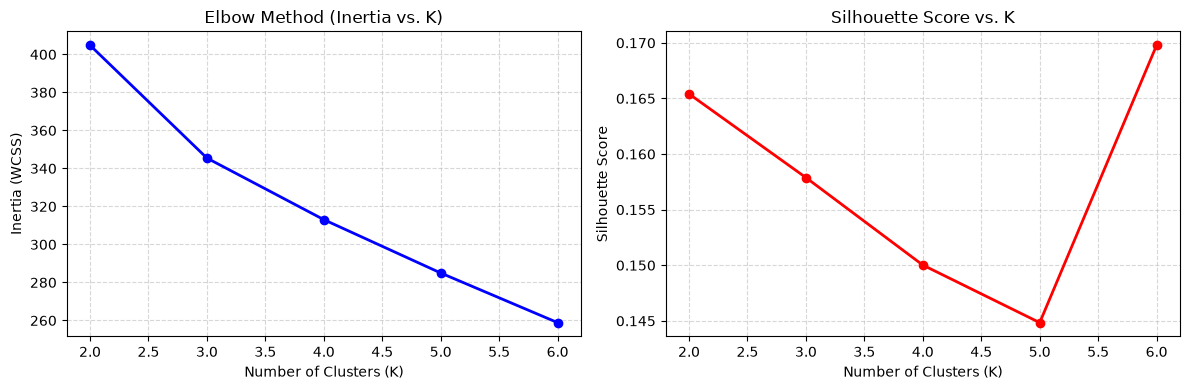

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select academic attributes for segmentation
cluster_features = ['Math', 'Science', 'English', 'Social', 'Attendance']
X_cluster = df_clean[cluster_features]

# Scale features so subject marks and attendance carry equal variance
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Evaluate K values from 2 to 6
wcss = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Plot Elbow and Silhouette evaluation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, wcss, 'bo-', linewidth=2)
ax1.set_title("Elbow Method (Inertia vs. K)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2)
ax2.set_title("Silhouette Score vs. K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# # Fit K-Means (K=3) & Profile Personas

In [61]:
import seaborn as sns

# Fit model using K=3 (typically separating Low, Medium, and High performing groups)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Calculate unscaled cluster centroids (means) to interpret student archetypes
cluster_profiles = df_clean.groupby('Cluster')[cluster_features].mean().round(1)
cluster_profiles['Student_Count'] = df_clean['Cluster'].value_counts()

# Assign descriptive persona labels based on mean marks
print("Cluster Academic Profiles:")
display(cluster_profiles)

Cluster Academic Profiles:


,Math,Science,English,Social,Attendance,Student_Count
Cluster,,,,,,
0,67.8,49.0,77.8,72.5,86.3,33
1,56.6,73.4,70.5,53.9,89.4,34
2,65.1,70.8,56.3,63.9,76.0,33


# #  Cluster Visualization

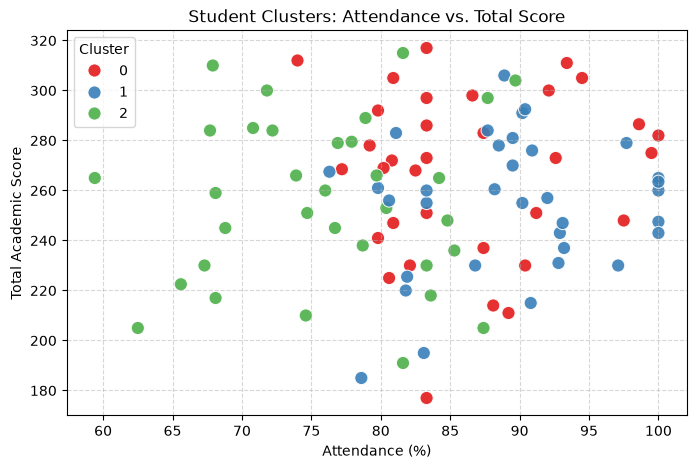

In [62]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x='Attendance',
    y='Total_Score',
    hue='Cluster',
    palette='Set1',
    s=90,
    alpha=0.9
)
plt.title("Student Clusters: Attendance vs. Total Score", fontsize=12)
plt.xlabel("Attendance (%)")
plt.ylabel("Total Academic Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# # REST API 

In [71]:
%%writefile api.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import pandas as pd
import joblib

app = FastAPI(
    title="Student Performance Prediction API",
    version="1.0.0",
    description="REST API to predict student pass probability and academic risk."
)

# 1. Load the trained pipeline
MODEL_PATH = "student_performance_logistic_model.pkl"

try:
    model = joblib.load(MODEL_PATH)
except Exception as e:
    raise RuntimeError(f"Could not load model at {MODEL_PATH}: {e}")

# 2. Define input schema using Pydantic
class StudentData(BaseModel):
    Age: float = Field(..., example=16.0)
    Math: float = Field(..., ge=0, le=100, example=65.0)
    Science: float = Field(..., ge=0, le=100, example=70.0)
    English: float = Field(..., ge=0, le=100, example=58.0)
    Social: float = Field(..., ge=0, le=100, example=62.0)
    Attendance: float = Field(..., ge=0, le=100, example=82.5)
    Enrollment_Year: int = Field(..., example=2023)
    Enrollment_Month: int = Field(..., ge=1, le=12, example=3)
    Gender: str = Field(..., example="Female")
    City: str = Field(..., example="Kathmandu")

# 3. Health check endpoint
@app.get("/")
def home():
    return {"status": "active", "message": "Student Performance API is running."}

# 4. Prediction endpoint
@app.post("/predict")
def predict_outcome(student: StudentData):
    try:
        # Convert request body into DataFrame matching model input format
        input_df = pd.DataFrame([student.model_dump()])
        
        # Calculate probability and predicted class
        prob_pass = float(model.predict_proba(input_df)[0][1])
        prediction = int(prob_pass >= 0.50)
        verdict = "Pass" if prediction == 1 else "At Risk / Fail"
        
        return {
            "prediction": prediction,
            "verdict": verdict,
            "pass_probability": round(prob_pass, 4)
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Writing api.py
